In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
TH_500 = pd.read_csv(
    "../classification/TomsHardware/Relative_labeling/sigma=500/TomsHardware-Relative-Sigma-500.data",
    sep=",",
    header=None
)

TH_1000= pd.read_csv(
    "../classification/TomsHardware/Relative_labeling/sigma=1000/TomsHardware-Relative-Sigma-1000.data",
    sep=",",
    header=None
)
TH_1500= pd.read_csv(
    "../classification/TomsHardware/Relative_labeling/sigma=1500/TomsHardware-Relative-Sigma-1500.data",
    sep=",",
    header=None
)


In [3]:
groups = [
    "NCD", "BL", "NAD", "AI", "NAC", "ND",
    "CS", "AT", "NA", "ADL", "AS_NA", "AS_NAC"
]

columns = []
for group in groups:
    for t in range(8):
        columns.append(f"{group}_{t}")

columns.append("label")  

TH_500.columns = columns
TH_1000.columns = columns
TH_1500.columns = columns

prefixes = {col.split("_")[0] for col in TH_500.columns if "_" in col}
prefixes = {col.split("_")[0] for col in TH_1000.columns if "_" in col}
prefixes = {col.split("_")[0] for col in TH_1500.columns if "_" in col}

TH_500.head(2)

,NCD_0,NCD_1,NCD_2,NCD_3,NCD_4,NCD_5,NCD_6,NCD_7,BL_0,BL_1,...,AS_NA_7,AS_NAC_0,AS_NAC_1,AS_NAC_2,AS_NAC_3,AS_NAC_4,AS_NAC_5,AS_NAC_6,AS_NAC_7,label
0,1,0,0,0,0,0,0,1,1.0,0.0,...,0.001816,0.001211,0.00056,0.0,0.0,0.000161,0.0,0.000301,0.000818,0.0
1,0,0,0,0,0,0,0,0,0.0,0.0,...,0.000000,0.000000,0.00000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0


In [5]:
TH_1000.head(2)

,NCD_0,NCD_1,NCD_2,NCD_3,NCD_4,NCD_5,NCD_6,NCD_7,BL_0,BL_1,...,AS_NA_7,AS_NAC_0,AS_NAC_1,AS_NAC_2,AS_NAC_3,AS_NAC_4,AS_NAC_5,AS_NAC_6,AS_NAC_7,label
0,1,0,0,0,0,0,0,1,1.0,0.0,...,0.001816,0.001211,0.00056,0.0,0.0,0.000161,0.0,0.000301,0.000818,0.0
1,0,0,0,0,0,0,0,0,0.0,0.0,...,0.000000,0.000000,0.00000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0


In [6]:
TH_1500.head(2)

,NCD_0,NCD_1,NCD_2,NCD_3,NCD_4,NCD_5,NCD_6,NCD_7,BL_0,BL_1,...,AS_NA_7,AS_NAC_0,AS_NAC_1,AS_NAC_2,AS_NAC_3,AS_NAC_4,AS_NAC_5,AS_NAC_6,AS_NAC_7,label
0,1,0,0,0,0,0,0,1,1.0,0.0,...,0.001816,0.001211,0.00056,0.0,0.0,0.000161,0.0,0.000301,0.000818,0.0
1,0,0,0,0,0,0,0,0,0.0,0.0,...,0.000000,0.000000,0.00000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0


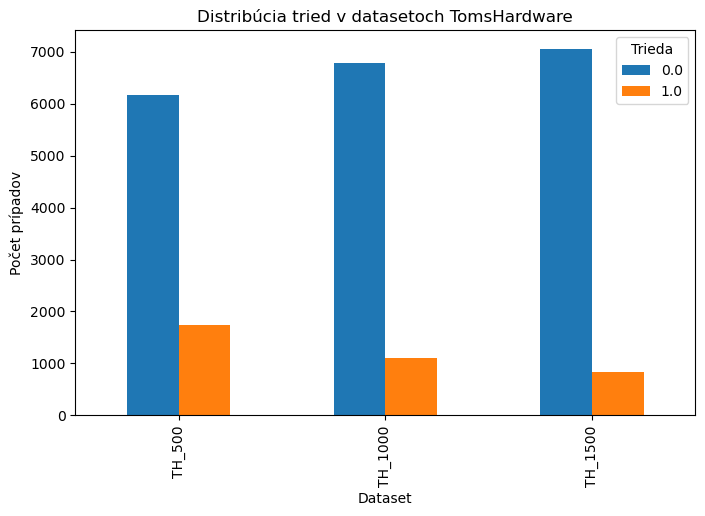

In [5]:
TH_500['label'].value_counts()
TH_1000['label'].value_counts()
TH_1500['label'].value_counts()

balance_df = pd.DataFrame({
    'TH_500': TH_500['label'].value_counts(),
    'TH_1000': TH_1000['label'].value_counts(),
    'TH_1500': TH_1500['label'].value_counts()
}).T

balance_df.plot(kind='bar', figsize=(8,5))

plt.title("Distribúcia tried v datasetoch TomsHardware")
plt.xlabel("Dataset")
plt.ylabel("Počet prípadov")
plt.legend(title="Trieda")
plt.show()

Vzhľadom na to, že súbory údajov sú nevyvážené, okrem presnosti sa budú používať aj hodnotiace metriky, ako napríklad F1-skóre, presnosť a recall.
